# California Housing Price Prediction - Linear Regression Assignment
1. **Simple Linear Regression** (single feature)
2. **Multiple Linear Regression** (all features)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('housing.csv')

##  Task 1: Simple Linear Regression (Single Feature)

## Step 1: Data Retrieval and Collection

In [3]:
df.shape

(20640, 10)

In [4]:
df.shape

(20640, 10)

In [5]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')>

In [91]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Step 2: Data Cleaning

## Handle miss#ing values and verify data integrity.

In [7]:
df.isnull().sum().sum()

np.int64(207)

In [9]:
# Handle missing values in total_bedrooms (if any)
if df['total_bedrooms'].isnull().sum() > 0:
    df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Drop rows with remaining missing values
df_clean = df.dropna()

**Explanation:**
- The `total_bedrooms` column typically contains missing values
- We fill missing values with the **median** (more robust than mean)
- All data types are numeric, appropriate for linear regression

## Step 3: Feature Design

In [15]:
# Select single feature and target
X= df_clean[['housing_median_age']].values
y = df_clean['median_house_value'].values

## Step 4: Algorithm Selection

**Algorithm:** Linear Regression

**Why Linear Regression?**
- Predicting a **continuous numerical value** (house price)
- Simple, interpretable, serves as a baseline model
- Assumes linear relationship: $y = mx + b$
  - $y$ = predicted house value
  - $x$ = housing median age
  - $m$ = slope (coefficient)
  - $b$ = y-intercept

## Step 5: Loss Function Selection

**Loss Function:** Mean Squared Error (MSE)

**What is MSE?**
- Measures average squared differences between predicted and actual values
- Formula: $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$
- **Lower MSE = Better performance**
- Squaring penalizes larger errors more heavily
- Default loss function minimized during training

## Step 6: Model Learning (Training)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
X_train.shape

(16512, 1)

In [19]:
model= LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Learning Process:**
- Uses **Ordinary Least Squares (OLS)** to find best-fit line
- Minimizes sum of squared residuals
- Calculates optimal coefficient and intercept

## Step 7: Model Evaluation

In [24]:
# Make predictions
y_pred= model.predict(X_test)

In [25]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

**Interpretation:**
- **MSE/RMSE:** Average prediction error (lower is better)
- **R² Score:** Proportion of variance explained (0-1, higher is better)
- Since we use only ONE feature, expect moderate performance

---

## Model Interpretation - Task 1

In [32]:
model.coef_

array([951.46186715])

In [33]:
model.intercept_

np.float64(179975.00158647486)

**What does the Coefficient represent?**
- Change in house value for each additional year of age
- Positive → house value increases with age
- Negative → house value decreases with age (depreciation)

**What does the Intercept mean?**
- Predicted house value when age = 0 (newly built)
- Baseline house value in the model

# Visualization (simple Data )

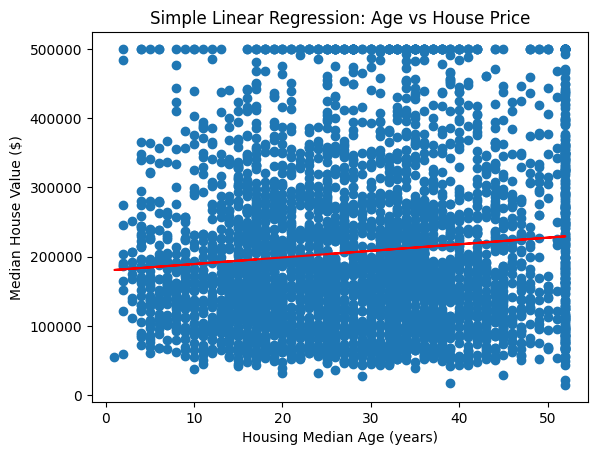

In [71]:
# Plot 1: Regression Line
plt.scatter(X_test, y_test, label='Actual Prices')
plt.plot(X_test, y_pred, color='red')
plt.xlabel('Housing Median Age (years)')
plt.ylabel('Median House Value ($)')
plt.title('Simple Linear Regression: Age vs House Price')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_5940\765987485.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


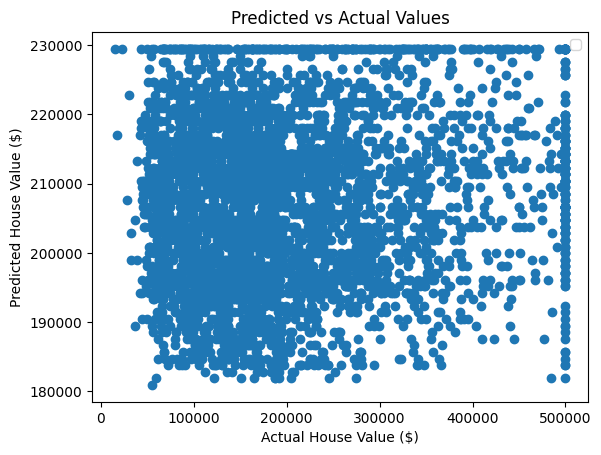

In [72]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.title('Predicted vs Actual Values')
plt.legend()
plt.show()

##  Task 2: Multiple Linear Regression (All Features)

# Feature Engi.

In [73]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'median_house_value' in numeric_cols:
    numeric_cols.remove('median_house_value')

In [74]:
# Create feature matrix
X_m= df_clean[numeric_cols].values
y = df_clean['median_house_value'].values

In [75]:
# Shapes 
X_m.shape

(20640, 8)

In [76]:
y.shape

(20640,)

## what we did at feature  Scaling.
- Features have different scales (e.g., total_rooms vs median_income)
- Linear regression can handle this, but coefficients will vary in magnitude
- Proceeding without scaling for simplicity

# FOR Multiple Linear Regression

**Why Multiple reg.?**
- Same as Task 1: predicting continuous values
- Now using multiple input features
- Model: $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$
- This is the poly. func

## Step 6: Model Train

In [77]:
# Split data (same random_state for fair comparison)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_m, y, test_size=0.2, random_state=42)

In [78]:
X_train_multi.shape

(16512, 8)

In [79]:
y_train_multi.shape

(16512,)

In [80]:
# Train the model
model_m = LinearRegression()
model_m.fit(X_train_multi, y_train_multi)

LinearRegression()

**Learning Process:**
- Uses OLS to find optimal coefficients
- Solves system of equations to minimize MSE across all features
- Each feature gets its own coefficient

## Model Evaluation

In [81]:
# Make predictions
y_pred_multi = model_m.predict(X_test_multi)

In [82]:
# Calculate metrics
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

# Evaluation of Meterics

**Interpretation:**
- **MSE/RMSE:** Should be significantly lower than Task 1
- **R² Score:** Should be much higher (closer to 1)
- Multiple features capture complex relationships

##  Model Interpretation - for multi

In [83]:
model_m.coef_

array([-4.26323917e+04, -4.24500719e+04,  1.18280965e+03, -8.18797708e+00,
        1.16260128e+02, -3.84922131e+01,  4.63425720e+01,  4.05384044e+04])

In [84]:
model_m.intercept_

np.float64(-3578224.234818668)

**What does each coefficient represent?**

Each coefficient shows the **change in house value** for a **one-unit increase** in that feature, **holding all other features constant**.

**Interpretation:**
- **Positive coefficients:** Feature increase → higher house prices
- **Negative coefficients:** Feature increase → lower house prices
- **Magnitude:** Larger absolute values = stronger influence

##  Visualization - Mutlti reg

C:\Users\DELL\AppData\Local\Temp\ipykernel_5940\4017499630.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


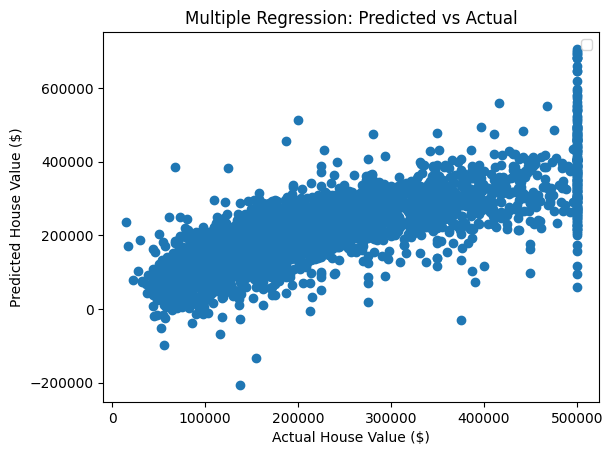

In [85]:
# prediction actual vs pred.
plt.scatter(y_test_multi, y_pred_multi)
plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.title('Multiple Regression: Predicted vs Actual')
plt.legend()
plt.show()

#  Model Comparison: simple vs Multiple Regression 

In [86]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R² Score', 'Number of Features'],
    'Simple Linear Regression': [
        f"${mse:}",
        f"${rmse:,.2f}",
        f"{r2:.4f}",
        "1"
    ],
    'Multiple Linear Regression': [
        f"${mse_multi:,.2f}",
        f"${rmse_multi:,.2f}",
        f"{r2_multi:.4f}",
        str(len(numeric_cols))
    ]
})

In [87]:
print("MODEL COMPARISON")
print(comparison.to_string(index=False))

MODEL COMPARISON
            Metric Simple Linear Regression Multiple Linear Regression
               MSE      $12939617265.100323          $5,059,928,371.17
              RMSE              $113,752.44                 $71,133.17
          R² Score                   0.0126                     0.6139
Number of Features                        1                          8


In [88]:
# Calculate improvements
mse_improvement = ((mse - mse_multi) / mse) * 100
r2_improvement = ((r2_multi - r2) / r2) * 100

In [89]:
mse_improvement

60.89584206781312

In [90]:
r2_improvement

4790.884837706188

##  Last Summary

### Which model performs better?
**Multiple Linear Regression (Task 2)** performs significantly better:
- **Lower MSE/RMSE:** More accurate predictions
- **Higher R² Score:** Explains more variance in house prices

### Why does using multiple features help?
1. **Captures complexity:** House prices depend on many factors (income, location, size, age)
2. **Reduces unexplained variance:** Single feature leaves much information unused
3. **Better generalization:** Model learns richer patterns from data

### Which model is easier to interpret?
**Simple Linear Regression (Task 1)** is easier to interpret:
- **One relationship:** Clear understanding of age vs price
- **Simple visualization:** Easy to plot and explain
- **Single coefficient:** Straightforward meaning

**Multiple Linear Regression** is more powerful but:
- **Many coefficients:** Harder to understand individual effects
- **Interaction effects:** Features may correlate with each other
- **Scaling issues:** Coefficients not directly comparable
